<a href="https://colab.research.google.com/github/dhia33rpl/Data-Diri/blob/main/praktikum_analisis_perfoma_penjualan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('data_praktikum_analisis.csv')
print(df.head())

   Order_ID  CustomerID  Order_Date Product_Category  Quantity  \
0      1001        5039  2023-08-19            Books         4   
1      1002        5029  2023-08-29          Fashion         5   
2      1003        5015  2023-02-21          Fashion         4   
3      1004        5043  2023-04-06          Fashion         2   
4      1005        5008  2023-08-10       Home Decor         2   

   Price_Per_Unit  Ad_Budget  Total_Sales  
0       1184000.0   982000.0    4736000.0  
1       1733000.0  3513000.0    8665000.0  
2       1767000.0  2117000.0    7068000.0  
3        512000.0  4384000.0    1024000.0  
4       1820000.0  2625000.0    3640000.0  


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          150 non-null    int64  
 1   CustomerID        150 non-null    int64  
 2   Order_Date        150 non-null    object 
 3   Product_Category  150 non-null    object 
 4   Quantity          150 non-null    int64  
 5   Price_Per_Unit    150 non-null    float64
 6   Ad_Budget         150 non-null    float64
 7   Total_Sales       143 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 9.5+ KB


In [9]:
df.isnull().sum()

,0
Order_ID,0
CustomerID,0
Order_Date,0
Product_Category,0
Quantity,0
Price_Per_Unit,0
Ad_Budget,0
Total_Sales,7


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ubah kolom tanggal jadi format datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# ambil bulan dari tanggal
df['Month'] = df['Order_Date'].dt.to_period('M')

# jumlahkan penjualan per bulan
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

print(monthly_sales)

Month
2023-01    19910000.0
2023-02    39524000.0
2023-03    24003000.0
2023-04    45084000.0
2023-05    50372000.0
2023-06    44580000.0
2023-07    21909000.0
2023-08    83500000.0
2023-09    42062000.0
2023-10    23454000.0
2023-11    34654000.0
2023-12    29025000.0
Freq: M, Name: Total_Sales, dtype: float64


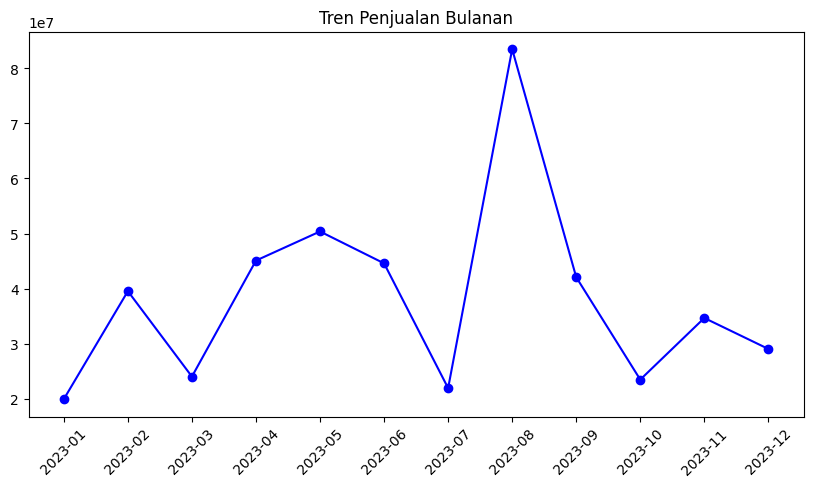

In [17]:
plt.figure(figsize=(10,5))
plt.title("Tren Penjualan Bulanan")
plt.plot(monthly_sales.index.astype(str),
         monthly_sales.values,
         marker='o',
         color='b')
plt.xticks(rotation=45)
plt.show()

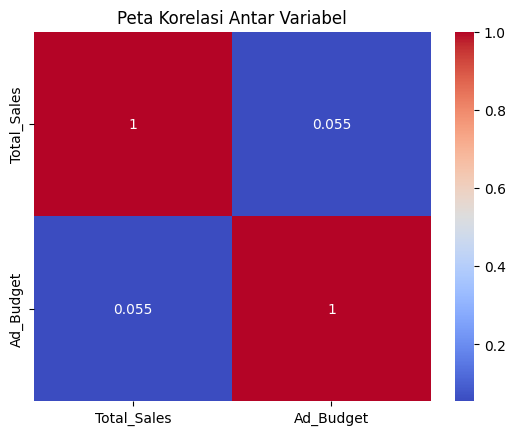

In [15]:
correlation = df[['Total_Sales', 'Ad_Budget']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antar Variabel')
plt.show()

TUGAS KELOMPOK SEBANGKU


Produk underperformer:
Product_Category
Gadget         31
Home Decor     43
Fashion        45
Books          51
Electronics    55
Name: Quantity, dtype: int64


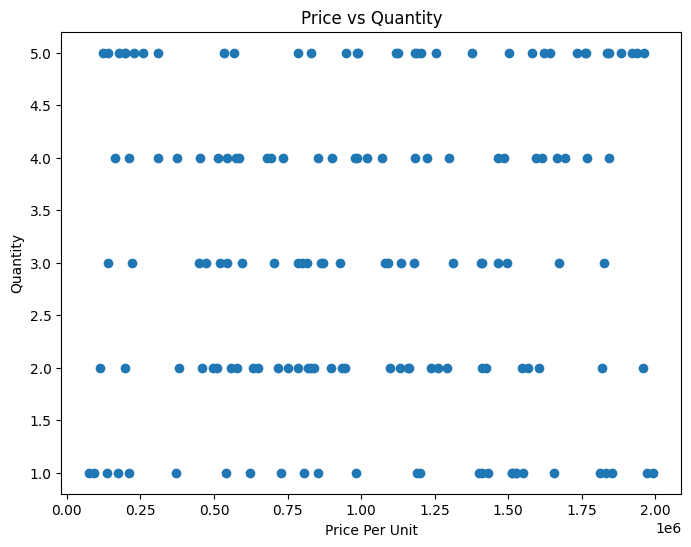

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# baca data
df = pd.read_csv('data_praktikum_analisis.csv')

# rata-rata harga
avg_price = df['Price_Per_Unit'].mean()

# filter produk harga tinggi
high_price = df[df['Price_Per_Unit'] > avg_price]

# total quantity kategori produk
underperformer = high_price.groupby('Product_Category')['Quantity'].sum().sort_values()

print("Produk underperformer:")
print(underperformer.head())

# scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df['Price_Per_Unit'], df['Quantity'])
plt.xlabel('Price Per Unit')
plt.ylabel('Quantity')
plt.title('Price vs Quantity')
plt.show()

In [22]:
import datetime as dt

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Group'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

print(rfm.head())


            Recency  Frequency    Monetary R_Score F_Score M_Score RFM_Group
CustomerID                                                                  
5001            213          4   8562000.0       1       4       3       143
5002             77          4   6931000.0       3       4       3       343
5003            118          3   9433000.0       3       2       3       323
5004            196          3  15368000.0       2       3       4       234
5005             23          2   9105000.0       5       2       3       523


Hasil Analisis Efisiensi Kategori:
                  Total_Sales   Ad_Budget  Efficiency
Product_Category                                     
Gadget             70523000.0  76539000.0    0.921400
Home Decor         69340000.0  64808000.0    1.069930
Fashion            96550000.0  82317000.0    1.172905
Books             107569000.0  89914000.0    1.196354
Electronics       114095000.0  79264000.0    1.439430


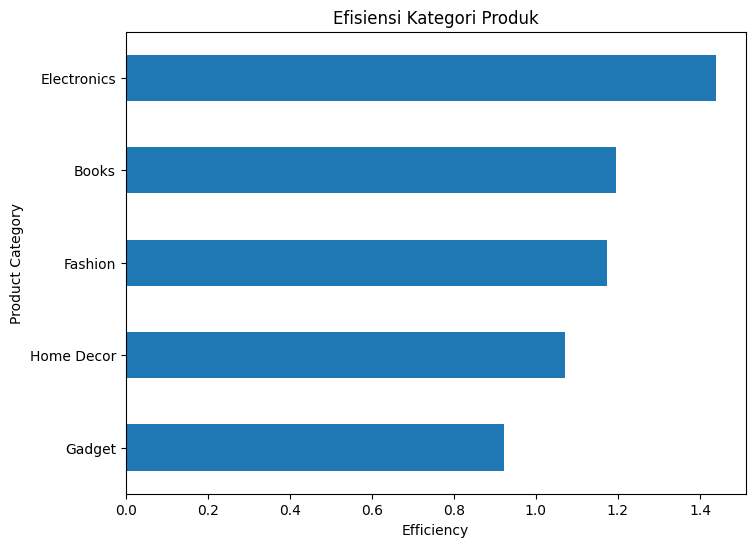

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# baca data
df = pd.read_csv('data_praktikum_analisis.csv')

df.columns = df.columns.str.strip()

category_analysis = df.groupby('Product_Category').agg({
    'Total_Sales': 'sum',
    'Ad_Budget': 'sum'
})

# hitung efisiensi
category_analysis['Efficiency'] = (
    category_analysis['Total_Sales'] /
    category_analysis['Ad_Budget']
)

# urutkan dari paling tidak efisien ke paling efisien
category_analysis = category_analysis.sort_values('Efficiency')

# tampilkan tabel hasil
print("Hasil Analisis Efisiensi Kategori:")
print(category_analysis)

# visualisasi bar chart horizontal
category_analysis['Efficiency'].plot(
    kind='barh',
    figsize=(8, 6)
)

plt.title('Efisiensi Kategori Produk')
plt.xlabel('Efficiency')
plt.ylabel('Product Category')
plt.show()

Median Ad_Budget: 2722500.0
Rata-rata Total Sales (Iklan Tinggi): 3156275.362318841
Rata-rata Total Sales (Iklan Rendah): 3247216.2162162163
Kesimpulan: Ad_Budget tinggi tidak menunjukkan peningkatan signifikan


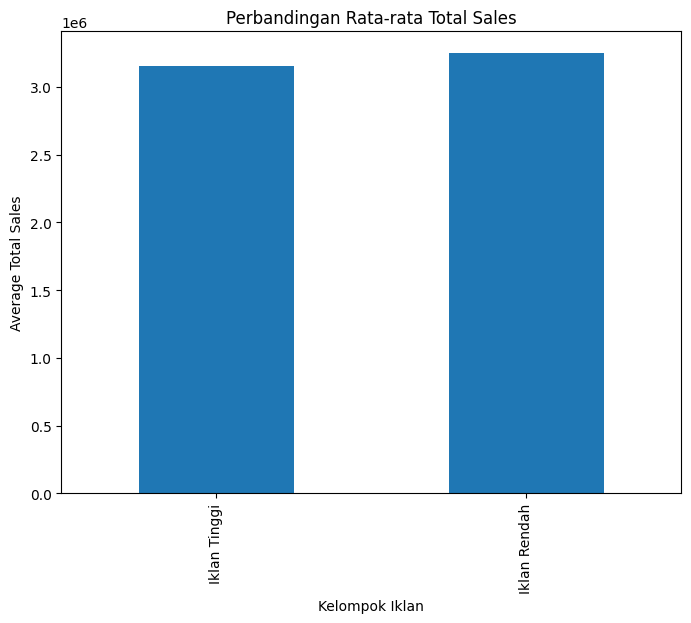

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# baca data
df = pd.read_csv('data_praktikum_analisis.csv')

# hapus spasi kalau ada
df.columns = df.columns.str.strip()

# cari median Ad_Budget
median_ad = df['Ad_Budget'].median()
print("Median Ad_Budget:", median_ad)

# bagi jadi 2 kelompok
high_ads = df[df['Ad_Budget'] > median_ad]
low_ads = df[df['Ad_Budget'] <= median_ad]

# hitung rata-rata sales
high_mean = high_ads['Total_Sales'].mean()
low_mean = low_ads['Total_Sales'].mean()

print("Rata-rata Total Sales (Iklan Tinggi):", high_mean)
print("Rata-rata Total Sales (Iklan Rendah):", low_mean)

# kesimpulan sederhana
if high_mean > low_mean:
    print("Kesimpulan: Ad_Budget tinggi cenderung meningkatkan Total_Sales")
else:
    print("Kesimpulan: Ad_Budget tinggi tidak menunjukkan peningkatan signifikan")

# visualisasi
sales_comparison = pd.Series({
    'Iklan Tinggi': high_mean,
    'Iklan Rendah': low_mean
})

sales_comparison.plot(kind='bar', figsize=(8,6))
plt.title('Perbandingan Rata-rata Total Sales')
plt.xlabel('Kelompok Iklan')
plt.ylabel('Average Total Sales')
plt.show()

In [28]:
import pandas as pd
import datetime as dt

# baca data
df = pd.read_csv('data_praktikum_analisis.csv')
df.columns = df.columns.str.strip()

# ubah Order_Date ke format tanggal
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# snapshot date = 1 hari setelah transaksi terakhir
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

# hitung RFM
rfm = df.groupby('CustomerID').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
})

# rename kolom
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# scoring 1-5
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates='drop'
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
)

# gabungkan skor
rfm['RFM_Group'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

print("Hasil RFM Analysis:")
print(rfm.head())

Hasil RFM Analysis:
            Recency  Frequency    Monetary R_Score F_Score M_Score RFM_Group
CustomerID                                                                  
5001            213          4   8562000.0       1       4       3       143
5002             77          4   6931000.0       3       4       3       343
5003            118          3   9433000.0       3       2       3       323
5004            196          3  15368000.0       2       3       4       234
5005             23          2   9105000.0       5       2       3       523


In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# baca data
df = pd.read_csv('data_praktikum_analisis.csv')
df.columns = df.columns.str.strip()

# hapus data kosong jika ada
df = df.dropna()

# fitur dan target
X = df[['Ad_Budget']]
y = df['Total_Sales']

# split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# buat model
model = LinearRegression()
model.fit(X_train, y_train)

# hasil
print("Koefisien Iklan:", model.coef_[0])
print("Akurasi Model (R2 Score):", model.score(X_test, y_test))

Koefisien Iklan: 0.1841982749623798
Akurasi Model (R2 Score): -0.1956467472142791
